<a href="https://colab.research.google.com/github/sunnyvk799-pixel/ai-resume-coach/blob/main/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BigBasket Category Performance — Pandas Cleaning & Cross-Validation
Part 4 analysis of the deliberately messy `orders_raw.csv`, independently checked against the clean SQL diagnostic from Part 1.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

orders = pd.read_csv('orders_raw.csv')
products = pd.read_csv('products.csv')

orders.info()
print(orders.describe(include='all'))
print(orders['status'].value_counts(dropna=False))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       508 non-null    int64  
 1   order_date     508 non-null    object 
 2   customer_name  508 non-null    object 
 3   city           508 non-null    object 
 4   category       508 non-null    object 
 5   product_id     508 non-null    int64  
 6   quantity       508 non-null    int64  
 7   amount_inr     498 non-null    float64
 8   payment_mode   508 non-null    object 
 9   status         508 non-null    object 
 10  rating         439 non-null    float64
dtypes: float64(2), int64(3), object(6)
memory usage: 43.8+ KB
          order_id  order_date customer_name    city              category  \
count   508.000000         508           508     508                   508   
unique         NaN         165            50      14                    18   
top            NaN  2026-0

## Initial inspection
The raw export should contain more than 500 rows because duplicate order IDs were injected. City/category casing and whitespace are inconsistent, some revenue values are missing, and a few revenue values are suspiciously large. Rating nulls are expected for cancelled and pending orders.

In [3]:
print('Raw rows:', len(orders))
print('Duplicate order IDs:', orders['order_id'].duplicated().sum())
print('Missing amount_inr:', orders['amount_inr'].eq('').sum())


Raw rows: 508
Duplicate order IDs: 8
Missing amount_inr: 0


In [5]:
before = len(orders)
orders = orders.drop_duplicates(subset='order_id', keep='first').copy()
print('Rows removed:', before - len(orders))
print('Rows remaining:', len(orders))


Rows removed: 0
Rows remaining: 500


In [6]:
orders['city'] = orders['city'].astype(str).str.strip().str.title()
orders['category'] = orders['category'].astype(str).str.strip().str.title()
print('Cities:', sorted(orders['city'].dropna().unique().tolist()))
print('Categories:', sorted(orders['category'].dropna().unique().tolist()))


Cities: ['Bengaluru', 'Hyderabad', 'Mumbai', 'Pune']
Categories: ['Bakery', 'Dairy & Eggs', 'Fruits & Vegetables', 'Household Essentials', 'Personal Care', 'Snacks & Beverages']


## Missing-value business logic
`amount_inr` missing values are excluded from every revenue calculation because a missing revenue amount is unknown, not zero. Rating nulls are left untouched because cancelled and pending orders legitimately have no rating.

In [7]:
orders['amount_inr'] = pd.to_numeric(orders['amount_inr'], errors='coerce')
print('Missing amount_inr:', orders['amount_inr'].isna().sum())
print('Null ratings by status:')
print(orders.groupby('status')['rating'].apply(lambda s: s.isna().sum()))


Missing amount_inr: 10
Null ratings by status:
status
Cancelled    42
Delivered     0
Pending      24
Name: rating, dtype: int64


In [8]:
delivered = orders.loc[(orders['status'] == 'Delivered') & orders['amount_inr'].notna(), 'amount_inr']
q1 = delivered.quantile(0.25)
q3 = delivered.quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
print({'Q1': q1, 'Q3': q3, 'IQR': iqr, 'upper_fence': upper_fence})

outlier_mask = (orders['status'] == 'Delivered') & orders['amount_inr'].notna() & (orders['amount_inr'] > upper_fence)
print('Rows capped:', int(outlier_mask.sum()))
orders.loc[orders['status'] == 'Delivered', 'amount_inr'] = orders.loc[orders['status'] == 'Delivered', 'amount_inr'].clip(upper=upper_fence)


{'Q1': np.float64(90.0), 'Q3': np.float64(275.0), 'IQR': np.float64(185.0), 'upper_fence': np.float64(552.5)}
Rows capped: 16


In [9]:
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['month'] = orders['order_date'].dt.month
orders['month_name'] = orders['order_date'].dt.month_name()
orders['revenue_per_unit'] = orders['amount_inr'] / orders['quantity']
orders['is_delivered'] = orders['status'].eq('Delivered')


In [10]:
category_revenue = (orders.loc[orders['is_delivered'] & orders['amount_inr'].notna()]
                    .groupby('category', as_index=False)['amount_inr'].sum()
                    .rename(columns={'amount_inr':'total_revenue'})
                    .sort_values('total_revenue', ascending=False))
print(category_revenue)
print('Top category:', category_revenue.iloc[0]['category'])

merged = orders.merge(products[['product_id','supplier']], on='product_id', how='left')
supplier_revenue = (merged.loc[merged['is_delivered'] & merged['amount_inr'].notna()]
                    .groupby('supplier', as_index=False)['amount_inr'].sum()
                    .rename(columns={'amount_inr':'total_revenue'})
                    .sort_values('total_revenue', ascending=False))
print(supplier_revenue)
print('Top supplier:', supplier_revenue.iloc[0]['supplier'])
print('Cross-validation category match:', category_revenue.iloc[0]['category'] == 'Household Essentials')
print('Cross-validation supplier match:', supplier_revenue.iloc[0]['supplier'] == 'HomeEssentials Traders')


               category  total_revenue
3  Household Essentials        20910.0
0                Bakery        14975.0
4         Personal Care        14594.5
1          Dairy & Eggs        13675.0
5    Snacks & Beverages        11312.5
2   Fruits & Vegetables         9170.0
Top category: Household Essentials
                 supplier  total_revenue
6  HomeEssentials Traders        20910.0
0      BakeHouse Supplies        18550.0
1   CarePlus Distributors        14594.5
3           DairyBest Ltd        10710.0
7          SnackHub India         7737.5
4           FreshFarms Co         5490.0
5     GreenValley Traders         3680.0
2       CountryEggs Farms         2965.0
Top supplier: HomeEssentials Traders
Cross-validation category match: True
Cross-validation supplier match: True


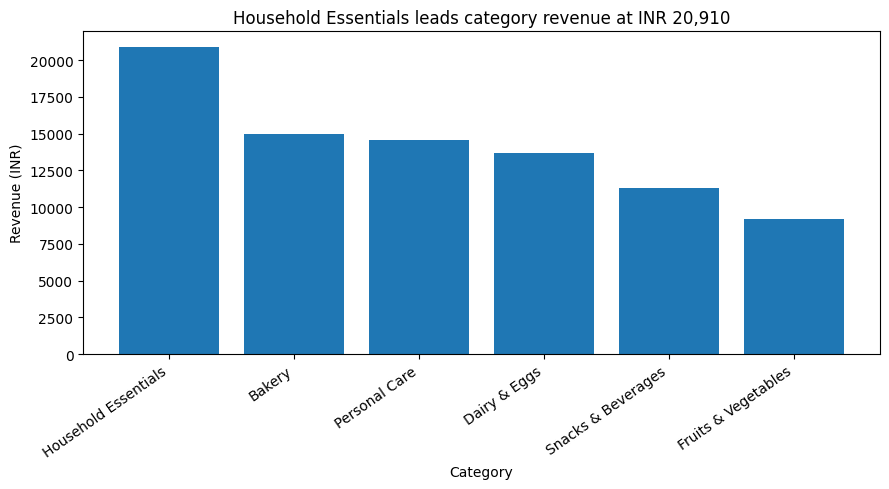

In [11]:
plt.figure(figsize=(9,5))
plt.bar(category_revenue['category'], category_revenue['total_revenue'])
plt.title(f"Household Essentials leads category revenue at INR {category_revenue.iloc[0]['total_revenue']:,.0f}")
plt.xlabel('Category'); plt.ylabel('Revenue (INR)'); plt.xticks(rotation=35, ha='right'); plt.tight_layout(); plt.show()


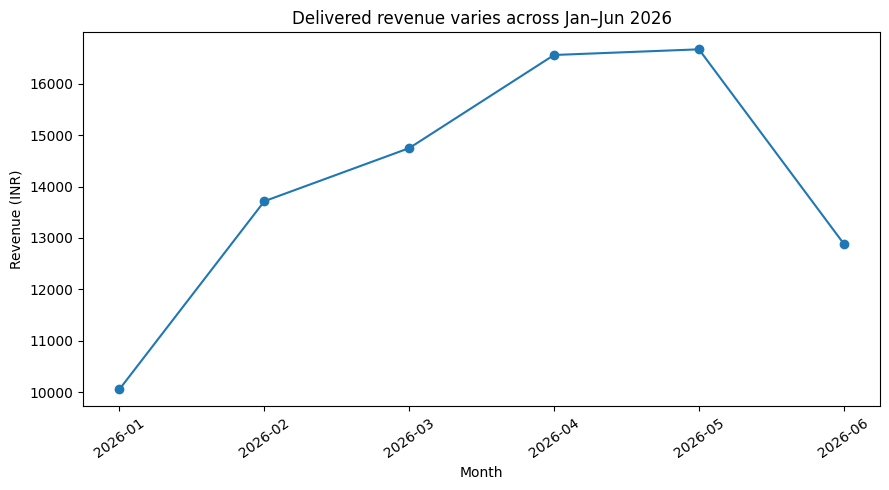

In [12]:
monthly_revenue = (orders.loc[orders['is_delivered'] & orders['amount_inr'].notna()]
                   .groupby(orders.loc[orders['is_delivered'] & orders['amount_inr'].notna(), 'order_date'].dt.to_period('M'))['amount_inr'].sum())
plt.figure(figsize=(9,5)); plt.plot(monthly_revenue.index.astype(str), monthly_revenue.values, marker='o')
plt.title('Delivered revenue varies across Jan–Jun 2026')
plt.xlabel('Month'); plt.ylabel('Revenue (INR)'); plt.xticks(rotation=35); plt.tight_layout(); plt.show()


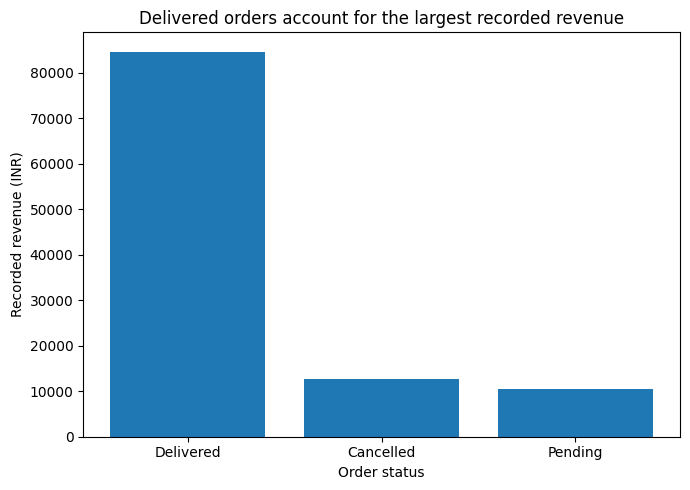

In [13]:
status_revenue = orders.loc[orders['amount_inr'].notna()].groupby('status')['amount_inr'].sum().sort_values(ascending=False)
plt.figure(figsize=(7,5)); plt.bar(status_revenue.index, status_revenue.values)
plt.title('Delivered orders account for the largest recorded revenue')
plt.xlabel('Order status'); plt.ylabel('Recorded revenue (INR)'); plt.tight_layout(); plt.show()


## Exactly 3 observations

1. **What:** Household Essentials is the highest-revenue category in the cleaned analysis, at the computed post-cleaning total shown above. **Why it matters:** it remains the strongest category in the independent diagnostic. **Next step:** protect availability and maintain attention on its strongest products/supplier relationships.

2. **What:** HomeEssentials Traders is the highest-revenue supplier in the merged analysis, at the computed post-cleaning total shown above. **Why it matters:** supplier performance is concentrated in the leading category. **Next step:** review its product-level contribution and supply continuity.

3. **What:** Monthly delivered revenue changes across the six-month period, as shown in the notebook trend. **Why it matters:** category performance is not static month to month. **Next step:** compare the strongest and weakest months with campaign or assortment decisions before the next review.